# Data Preprocessing for ML

**This aspect of ML is more art and less science and you often have to test different combinations. If you want to check if some process is useful, try with it and without it, both.**

In [36]:
%pip install -q numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

> We will be working with the California Housing Dataset to understand how to preprocess data for ML tasks

In [38]:
from sklearn.datasets import fetch_california_housing

# Fetch the dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Remove duplicate rows

df.drop_duplicates(inplace=True)
target_column = "median_house_value"

print(f'Total number of datapoints: {len(df)}')
print(f'Number of input columns: {len(df.columns)-1}')
print(f"Feature columns: {list(df.columns.drop(target_column))}")
print(f'Target Column = {target_column}')

Total number of datapoints: 20640
Number of input columns: 9
Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Target Column = median_house_value


## Step 1: Handle missing values

| Method | When to Use |
|---|---|
| **Drop the column with missing values** | When only a few datapoints have that column value missing only in training data |
| **Drop the column with missing values** | When many values in that column are missing and there is no use of rest of the values alone. |
| **Mean Imputation** | When the column values is evenly distributed and does not have any massive outliers |
| **Median Imputation** | When column values are continuous and have outliers |
| **Mode Imputation** | When column values are categorical. |

In [39]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [40]:
df['total_bedrooms'].describe()

# Here the column has outliers.
# We can observe this by looking at the mean and maximum, minimum

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [41]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = median_imputer.fit_transform(df[['total_bedrooms']])

> **NOTE**: Remove or fix illogical data in your dataset. This can be discovered using domain knowledge / analysing datapoints with attribute names.

> **Example**: Delivery Days field has datapoints with negative values 🤡

## Step 2: Encode the features

### Case A: The feature is categorical

##### Label Encoding/ Ordinal Encoding

Label Encoding involves assigning a unique integer to each distinct category within a feature column

**Example:**
```text
"red"   -> 0
"blue"  -> 1
"green" -> 2
```

##### One-Hot Encoding

The previous encoding approach can unintentionally introduce an implicit mathematical ordering that might confuse models. For example, a model might incorrectly assume that "green" is mathematically larger than "blue".

**One-Hot Encoding** prevents this false numerical ordering by creating separate, independent binary columns (0s and 1s) for each category.

**Example (Standard One-Hot Encoding):**
```text
"red"   -> [1, 0, 0]
"blue"  -> [0, 1, 0]
"green" -> [0, 0, 1]
```

> 💡 We can drop one of the columns since it is obvious that if we have only three classes of the attribute and red,blue is [0,0] then it is green.

```text
"red"   -> [1, 0]
"blue"  -> [0, 1]
"green" -> [0, 0]
```

##### Target Encoding

Target Encoding replaces a categorical value with the mean of the target variable for that specific category.

$$Encoded\ Label = \frac{(n \times Category\ Mean) + (
    \lambda \times Overall\ Mean)}{n + \lambda}$$

n = The number of rows (data points) for that specific category.

$\lambda$ = A smoothing parameter (hyperparameter) chosen by the user. It represents the "weight" of the overall mean.

**Increasing $\lambda$** shrinks the estimates of rare categories closer to the overall global mean, preventing the model from memorizing statistical noise associated with low-frequency data.

**Decreasing $\lambda$** allows the model to trust the well-represented local categorical averages, capturing true, subtle patterns without over-smoothing the data.

| Method | When to Use |
|---|---|
| **One Hot Encoding** | Number of unique categories is less and there is no existing heirarchy |
| **Ordinal encoding** for input columns and **Label Encoding** for target column | Number of unique categories is more and there is an existing heirarchy |
| **Target Encoding** | Number of unique categories is more and there is no existing heirarchy  |

> You can encode string columns too using the above methods, alternatively you can also try basic hashing techniques to hash the string and use the hash as your encoding.

In [42]:
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(df.nunique())

# Based on this we can tell that ocean_proximity is a categorical field

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64


In [43]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [44]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[['ISLAND', 'NEAR OCEAN', 'NEAR BAY','<1H OCEAN','INLAND']])
df['ocean_proximity'] = enc.fit_transform(df[['ocean_proximity']])

## Step 3: Remove Skewness from Columns

In many machine learning algorithms, we assume that feature columns are normally distributed (Gaussian). However, data is often skewed, meaning there is an asymmetry in its distribution. The mean is shifted to the left or to the right, rather than being centered. 

**Types of Skewness:**
*   **Left Skew (Negative Skew):** The left tail of the distribution is thicker or longer. This implies that the bulk of the data is concentrated on the higher end (right), with a few unusually low values stretching the tail to the left.
*   **Right Skew (Positive Skew):** The right tail of the distribution is thicker or longer. This implies that the bulk of the data is concentrated on the lower end (left), with a few unusually high values stretching the tail to the right.

**How to Identify Skewness:**
You cannot reliably detect skew just by looking at raw tabular data. There are two primary ways to identify it:
1.  **Visually (Histograms):** You can visualize the distribution using **histogram plots** to see the shape of the data and identify which tail is thicker.
2.  **Numerically (Pandas `.skew()`):** You can use the `df.skew()` or `df['column'].skew()` function in Pandas to calculate the skewness mathematically. 
    *   If `skew() > 0`: The data is **Right Skewed** (Positive Skew).
    *   If `skew() < 0`: The data is **Left Skewed** (Negative Skew).
    *   If `skew()` is close to `0` (e.g., between -0.5 and 0.5): The data is generally considered symmetrical or normally distributed.


**How to Fix Skewness:**
*   **Left Skew:** Apply `np.exp()` or $x^2$. 
    *   *Why it works:* It disproportionately stretches out the clustered higher values on the right, balancing the long left tail.
*   **Right Skew:** Apply `np.log()` or $\sqrt{x}$.
    *   *Why it works:* It heavily compresses the large values on the right, pulling in the long right tail.
    *   *Note:* Data must be > 0. If you have negative numbers or zeros, add a constant first (e.g., `np.log(x + c)`).

| Type of Skew | How to Identify | How to Fix |
| :--- | :--- | :--- |
| **Left Skew** (Negative) | `.skew() < 0` | Apply `np.exp()` or $x^2$ |
| **Right Skew** (Positive) | `.skew() > 0` | Apply `np.log()` or $\sqrt{x}$ |


In [45]:
# A common threshold for skewness is 0.5
# > 0.5 is Right Skewed, < -0.5 is Left Skewed
threshold = 0.5 
numerical_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

print(f"{'Column Name':<25} | {'Skew Value':<10} | {'Status'}")
print("-" * 70)

right_skewed_columns = []
left_skewed_columns = []

for col in numerical_cols:
    skew_val = df[col].skew()
    
    if skew_val > threshold:
        right_skewed_columns.append(col)
        status = "Right Skewed (Needs Log/Sqrt)"
    elif skew_val < -threshold:
        left_skewed_columns.append(col)
        status = "Left Skewed (Needs Exp/Square)"
    else:
        status = "Fine (Symmetrical)"
        
    # Print formatted output
    print(f"{col:<25} | {skew_val:>10.3f} | {status}")

Column Name               | Skew Value | Status
----------------------------------------------------------------------
longitude                 |     -0.298 | Fine (Symmetrical)
latitude                  |      0.466 | Fine (Symmetrical)
housing_median_age        |      0.060 | Fine (Symmetrical)
total_rooms               |      4.147 | Right Skewed (Needs Log/Sqrt)
total_bedrooms            |      3.481 | Right Skewed (Needs Log/Sqrt)
population                |      4.936 | Right Skewed (Needs Log/Sqrt)
households                |      3.410 | Right Skewed (Needs Log/Sqrt)
median_income             |      1.647 | Right Skewed (Needs Log/Sqrt)


RIGHT SKEWED COLUMNS

Feature: total_rooms
  Before Skewness:   4.147
  After Skewness :  -1.076


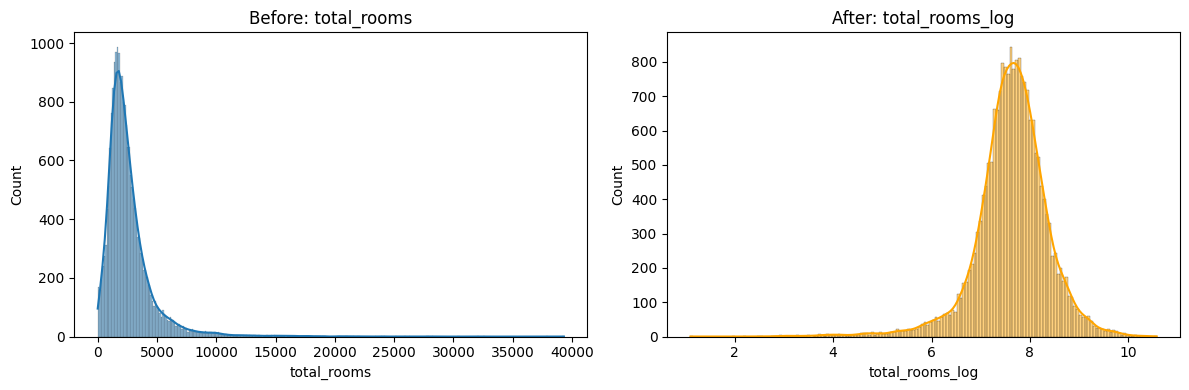


Feature: total_bedrooms
  Before Skewness:   3.481
  After Skewness :  -0.999


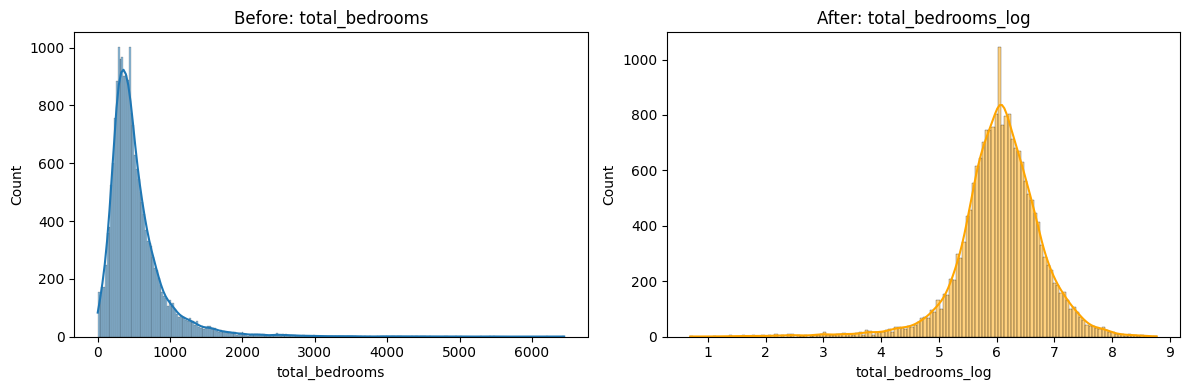


Feature: population
  Before Skewness:   4.936
  After Skewness :  -1.044


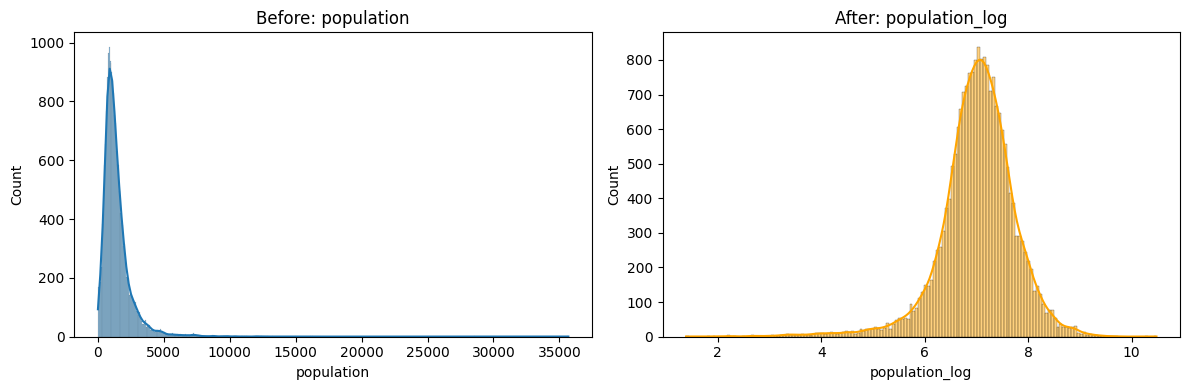


Feature: households
  Before Skewness:   3.410
  After Skewness :  -1.052


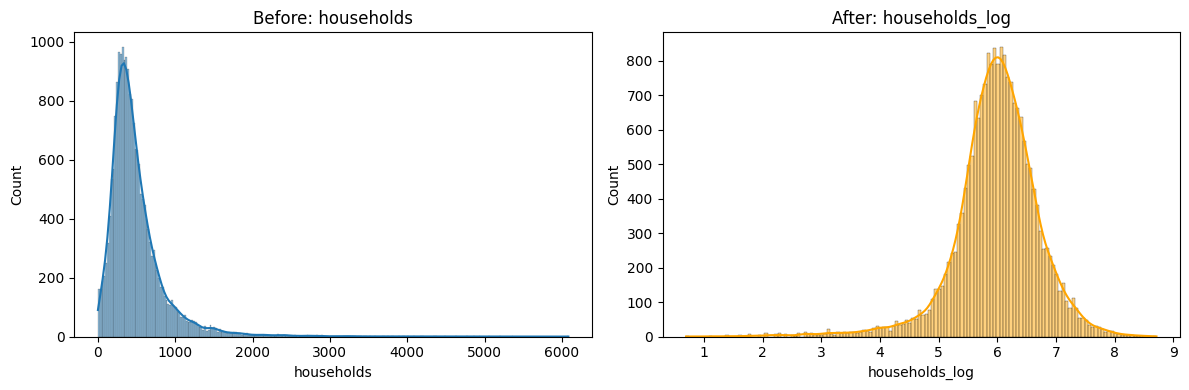


Feature: median_income
  Before Skewness:   1.647
  After Skewness :   0.226


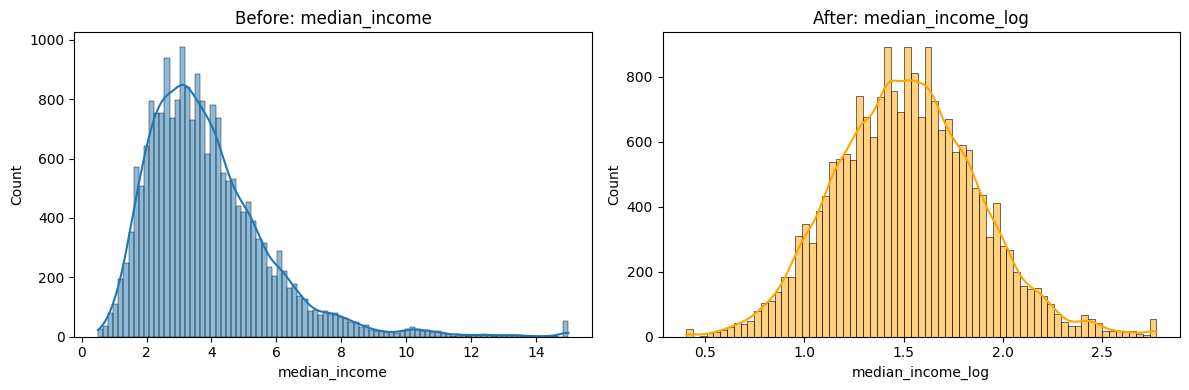

In [46]:
# 1. Process Right Skewed Columns (Log Transformation)
if right_skewed_columns:
    print("RIGHT SKEWED COLUMNS")
    
    for col in right_skewed_columns:
        transformed_col_name = f"{col}_log"
        df[transformed_col_name] = np.log1p(df[col]) # Safely apply log(1+x)
        
        print(f"\nFeature: {col}")
        print(f"  Before Skewness: {df[col].skew():>7.3f}")
        print(f"  After Skewness : {df[transformed_col_name].skew():>7.3f}")
        
        # Plot side-by-side
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Before: {col}')
        
        plt.subplot(1, 2, 2)
        sns.histplot(df[transformed_col_name], kde=True, color='orange')
        plt.title(f'After: {transformed_col_name}')
        
        plt.tight_layout()
        plt.show()

# 2. Process Left Skewed Columns (Square Transformation)
if left_skewed_columns:
    print("LEFT SKEWED COLUMNS")
    
    for col in left_skewed_columns:
        transformed_col_name = f"{col}_squared"
        df[transformed_col_name] = np.square(df[col]) # Square handles left skew safely
        
        print(f"\nFeature: {col}")
        print(f"  Before Skewness: {df[col].skew():>7.3f}")
        print(f"  After Skewness : {df[transformed_col_name].skew():>7.3f}")
        
        # Plot side-by-side
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Before: {col}')
        
        plt.subplot(1, 2, 2)
        sns.histplot(df[transformed_col_name], kde=True, color='green')
        plt.title(f'After: {transformed_col_name}')
        
        plt.tight_layout()
        plt.show()

## Step 4: Handle Outliers

There are several techniques to handle outliers:

1. Remove the datapoints with outliers. This is simplest and the most wasteful method.

2. Cap the outliers at a certain lower and upper bound. These lower and upper bounds can be choosen using various methods like Quartiles or Median or using mean plus or minus standard deviation.

### Detecting Outliers

Outliers can often be detected by examining descriptive statistics (like `min`, `max`, `quartiles`) or visualizing data distributions (e.g., box plots, histograms). A common statistical method is using the Interquartile Range (IQR).

**Interquartile Range (IQR)**: It is the range between the first quartile (Q1) and the third quartile (Q3). Values significantly outside the range `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` are often considered outliers.

### Handling Outliers: Capping

Capping, also known as winsorization, involves replacing outlier values with a specified maximum or minimum value (e.g., a certain percentile). This prevents extreme values from unduly influencing model training while retaining the data points.

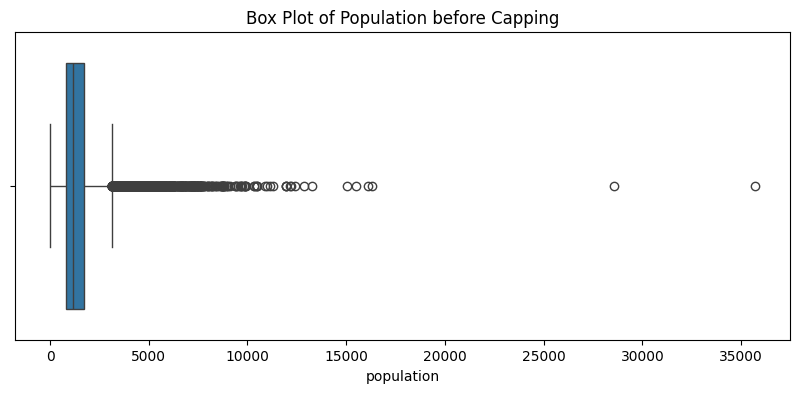

'population' column capped. Values below 348.00 are set to 348.00, and values above 3288.00 are set to 3288.00.


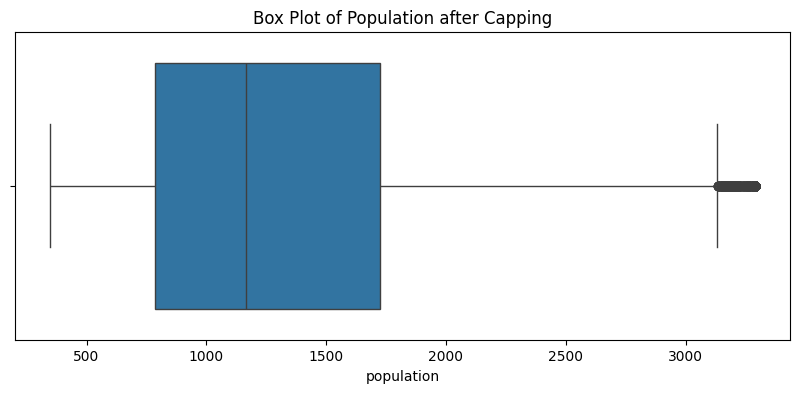

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize 'population' distribution before capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['population'])
plt.title('Box Plot of Population before Capping')
plt.show()

# Define Upper and Lower limits (e.g., 5th and 95th percentiles)
lower_limit = df['population'].quantile(0.05)
upper_limit = df['population'].quantile(0.95)

# Cap the outliers: values above the upper_limit become upper_limit, 
# and values below the lower_limit become lower_limit
df['population'] = np.where(
    df['population'] > upper_limit, 
    upper_limit,
    np.where(
        df['population'] < lower_limit, 
        lower_limit, 
        df['population']
    )
)

print(f"'population' column capped. Values below {lower_limit:.2f} are set to {lower_limit:.2f}, and values above {upper_limit:.2f} are set to {upper_limit:.2f}.")

# Visualize 'population' distribution after capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['population'])
plt.title('Box Plot of Population after Capping')
plt.show()

## Step 5: Feature Scaling & Transformation

Scaling puts all features on the same magnitude. Without this, models will be biased toward large numbers (e.g., treating "Salary=100,000" as more important than "Age=50").

### Common Scaling Techniques:

#### 1. Standard Scaler (Z-Score Normalization)
**Formula:** $$z = \frac{x - \mu}{\sigma}$$
**Effect:** Centers the data around 0 with a standard deviation of 1.
* **When to use:** The default choice for most algorithms
* **Assumption:** Assumes the underlying data is roughly *normally distributed* (Gaussian).

#### 2. MinMax Scaler (Normalization)
**Formula:** $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
**Effect:** Compresses data into a fixed range, usually `[0, 1]`.
* **When to use:**
    * when requiring bounded inputs (e.g., `[0,1]`) for tabular regression tasks.
    * algorithms that do not assume any distribution.
* **Problem:** Highly sensitive to *outliers*. One massive outlier squashes all other data to 0.

#### 3. Robust Scaler (Outlier-Proof)
**Formula:** Uses the Median and Interquartile Range (IQR). 
$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1}$$
* **When to use:** When your data contains *significant outliers*.

### Summary: When to Use What and Why

| Scaler | When to Use | Why / Effect |
| :--- | :--- | :--- |
| **Standard Scaler** | Default choice for most algorithms | Best when data is roughly normally distributed. Centers data at 0 with standard deviation of 1. |
| **MinMax Scaler** | Algorithms that don't assume a distribution or require bounded inputs. | Compresses data to a strict `[0, 1]` range. But highly sensitive to outliers. |
| **Robust Scaler** | When your dataset contains significant outliers. | Uses Median and IQR, so extreme outliers won't distort the scaling of your normal data. |


> This is only for continuous datapoints

In [48]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical columns for scaling (excluding the target and already transformed/encoded columns)
# We'll scale 'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income_log'

# Create a list of numerical columns to scale
columns_to_scale = [
    'longitude', 'latitude', 'housing_median_age',
    'total_rooms', 'total_bedrooms', 'population', 'households',
    'median_income_log'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Features successfully scaled using StandardScaler.")

# Display the first few rows with scaled features
display(df.head())

# You can also check the mean and std dev of scaled columns (should be ~0 and ~1)
print("\nMean of scaled features:")
print(df[columns_to_scale].mean())
print("\nStandard deviation of scaled features:")
print(df[columns_to_scale].std())

df.to_csv('processed_data.csv', index=False)
print("Data successfully saved to 'processed_data.csv'")

Features successfully scaled using StandardScaler.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_rooms_log,total_bedrooms_log,population_log,households_log,median_income_log
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-1.296579,-0.977033,8.3252,452600.0,2.0,6.781058,4.867534,5.777652,4.844187,1.995505
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,1.352224,1.669961,8.3014,358500.0,2.0,8.867850,7.009409,7.784057,7.037906,1.988380
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-1.105627,-0.843637,7.2574,352100.0,2.0,7.291656,5.252273,6.208590,5.181784,1.656444
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-1.025634,-0.733781,5.6431,341300.0,2.0,7.150701,5.463832,6.326149,5.393628,1.049948
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-1.016603,-0.629157,3.8462,342200.0,2.0,7.395108,5.638355,6.338594,5.560682,0.170631



Mean of scaled features:
longitude            -8.526513e-15
latitude             -1.079584e-15
housing_median_age    5.508083e-18
total_rooms           3.201573e-17
total_bedrooms       -9.363741e-17
population           -1.087846e-16
households            6.885104e-17
median_income_log    -1.597344e-16
dtype: float64

Standard deviation of scaled features:
longitude             1.000024
latitude              1.000024
housing_median_age    1.000024
total_rooms           1.000024
total_bedrooms        1.000024
population            1.000024
households            1.000024
median_income_log     1.000024
dtype: float64
Data successfully saved to 'processed_data.csv'


## Feature Engineering

**Keep features which show a lot of discriminative power and provide maximum coverage of the data as that is what helps the model learn patterns and predict outcomes.**

Example: A column for which all data points have the same value does not help the model at all.

**Try to create non-linear features out of existing features, you can analyse correlation matrix or utilise domain knowledge for that dataset to come up with these features**

Example: To classify if a person is healthy given height and weight. We can create a new feature named BMI using height and width.

**Another approach is to look at how much importance the model is giving to each feature and analyse which features to improve, discard or to build upon.**

*How to check this ?*
- ```model.feature_importances_``` is available for a few models
- for linear models check their weight matrices

## Train-Validation Splits in Dataset

### Hold-out Validation

In [49]:
X = df.drop(target_column, axis=1)
y = df[target_column]

We can have 20% of the randomly sampled for validation and use the rest for training.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Normally this is the type of split we use and is very effective when our dataset is very large.

### K-Fold Cross validation

We split the dataset into ```k``` equal splits. We train on ```k-1``` splits and validate on one split.

In [51]:
from sklearn.model_selection import KFold

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"--- Fold {fold + 1} ---")
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

--- Fold 1 ---
--- Fold 2 ---
--- Fold 3 ---
--- Fold 4 ---
--- Fold 5 ---


This validation strategy is used when we want to do hyperparameter tuning or when our dataset is small to medium sized.

There are improved versions of K-Fold cross validation like **Stratified K-Fold** which prevents class imbalance

### Leave-One-Out Cross Validation

It trains the model on all data points except one, and uses that single point for validation. It repeats this for every single data point.

In [52]:
'''
from sklearn.model_selection import LeaveOneOut

# Initialize LeaveOneOut (no parameters needed)
loo = LeaveOneOut()

for fold, (train_index, val_index) in enumerate(loo.split(X)):
    # val_index will always contain exactly 1 item
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
'''

'\nfrom sklearn.model_selection import LeaveOneOut\n\n# Initialize LeaveOneOut (no parameters needed)\nloo = LeaveOneOut()\n\nfor fold, (train_index, val_index) in enumerate(loo.split(X)):\n    # val_index will always contain exactly 1 item\n    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]\n    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]\n'

This is to be used only on extremely small datasets as it is very computationally expensive.

### Time Series Split

Splits data while respecting chronological order. In the first fold, it trains on day 1 and tests on day 2. In the second fold, it trains on days 1+2 and tests on day 3, and so on.

In [53]:
from sklearn.model_selection import TimeSeriesSplit

k = 5
tscv = TimeSeriesSplit(n_splits=k)

for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    print(f"--- Fold {fold + 1} ---")
    
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    print(f"Training set size: {len(train_index)}, Validation set size: {len(val_index)}")

--- Fold 1 ---
Training set size: 3440, Validation set size: 3440
--- Fold 2 ---
Training set size: 6880, Validation set size: 3440
--- Fold 3 ---
Training set size: 10320, Validation set size: 3440
--- Fold 4 ---
Training set size: 13760, Validation set size: 3440
--- Fold 5 ---
Training set size: 17200, Validation set size: 3440


> **NOTE**: ```TimeSeriesSplit``` is completely blind to actual dates or times. It does not look at your columns at all. It strictly relies on the row order (index) of the data you pass into it.

> So in order to do actual chronogical splits, you have to previously sort the dataset on the time based columns

This is used for Time Series forecasting (like predicting stock prices or weather). 

If you use standard K-Fold on time-series data, you will accidentally train your model on future data to predict the past, which ruins the evaluation.

## Some tips

Use **scikit-learn's Pipelines** for writing neat preprocessing code and enabling quick and easy modifications. They chain multiple preprocessing steps and a final model into a single object, keeping code clean and preventing data leakage during cross-validation.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Define the pipeline steps
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

| | `.fit()` | `.fit_transform()` | `.transform()` |
| :--- | :--- | :--- | :--- |
| **What they do** | Learns parameters (e.g., mean, standard deviation) from the data without altering it. | Learns the parameters from the data and immediately applies the transformation to it. | Applies the transformation using the parameters already learned from the training data. |
| **When to use them** | When you only need to calculate parameters to use later (rarely used alone). | On your **training data**. | On your **test/validation data** or any new, unseen data. |

## References

* [Geeks For Geeks](https://www.geeksforgeeks.org/machine-learning/ml-understanding-data-processing/)
* [Scikit documentation](https://scikit-learn.org/stable/modules/preprocessing.html)
